In [3]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [7]:
import os
import random
import shutil
from PIL import Image
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [8]:
!pip install kaggle
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json
!kaggle datasets download -d shaunthesheep/microsoft-catsvsdogs-dataset
!unzip -q microsoft-catsvsdogs-dataset.zip -d /content

Dataset URL: https://www.kaggle.com/datasets/shaunthesheep/microsoft-catsvsdogs-dataset
License(s): other
 97% 762M/788M [00:07<00:00, 203MB/s]
100% 788M/788M [00:07<00:00, 111MB/s]


In [9]:
import os

path = "/content/PetImages"
print(os.listdir(path))

['Cat', 'Dog']


In [10]:
dog_count = len(os.listdir("/content/PetImages/Dog"))
cat_count = len(os.listdir("/content/PetImages/Cat"))

print("Dog images:", dog_count)
print("Cat images:", cat_count)

Dog images: 12501
Cat images: 12501


In [11]:
dataset_path = 'PetImages'
classes = ['Cat', 'Dog']

# 1. Identify and remove corrupted images
for cls in classes:
    path = os.path.join(dataset_path, cls)
    for img_name in os.listdir(path):
        img_path = os.path.join(path, img_name)
        try:
            img = Image.open(img_path)
            img.verify()
        except (IOError, SyntaxError):
            print(f'Removing (Corrupted/Invalid): {img_path}')
            os.remove(img_path)

Removing (Corrupted/Invalid): PetImages/Cat/Thumbs.db
Removing (Corrupted/Invalid): PetImages/Cat/666.jpg


/usr/local/lib/python3.12/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))


Removing (Corrupted/Invalid): PetImages/Dog/11702.jpg
Removing (Corrupted/Invalid): PetImages/Dog/Thumbs.db


In [12]:
# 2. Balance the dataset (Fixed the variable order here)
cat_images = os.listdir(os.path.join(dataset_path, 'Cat'))
dog_images = os.listdir(os.path.join(dataset_path, 'Dog'))

# Calculate the minimum count first
min_count = min(len(cat_images), len(dog_images))

def balance_folder(folder_path, target_count):
    current_images = os.listdir(folder_path)
    if len(current_images) > target_count:
        to_remove = random.sample(current_images, len(current_images) - target_count)
        for img in to_remove:
            os.remove(os.path.join(folder_path, img))

# Balance both folders to the same size
balance_folder(os.path.join(dataset_path, 'Cat'), min_count)
balance_folder(os.path.join(dataset_path, 'Dog'), min_count)

print(f"Dataset successfully cleaned and balanced at {min_count} images per class.")

Dataset successfully cleaned and balanced at 12499 images per class.


In [13]:
dog_count = len(os.listdir("/content/PetImages/Dog"))
cat_count = len(os.listdir("/content/PetImages/Cat"))

print("Dog images:", dog_count)
print("Cat images:", cat_count)

Dog images: 12499
Cat images: 12499


In [14]:
output = "SplitData"
for split in ["train", "val", "test"]:
    for cls in classes:
        os.makedirs(os.path.join(output, split, cls), exist_ok=True)

for cls in classes:
    files = os.listdir(os.path.join(dataset_path, cls))
    random.shuffle(files)

    train_split = int(len(files) * 0.8)
    val_split = int(len(files) * 0.1)

    # Copy files to respective split folders
    for f in files[:train_split]:
        shutil.copy(os.path.join(dataset_path, cls, f), os.path.join(output, "train", cls, f))
    for f in files[train_split : train_split + val_split]:
        shutil.copy(os.path.join(dataset_path, cls, f), os.path.join(output, "val", cls, f))
    for f in files[train_split + val_split :]:
        shutil.copy(os.path.join(dataset_path, cls, f), os.path.join(output, "test", cls, f))

print("Data splitting complete.")

Data splitting complete.


In [15]:
datagen = ImageDataGenerator(rescale=1./255) # Normalization

train_gen = datagen.flow_from_directory(
    'SplitData/train',
    target_size=(128, 128),
    batch_size=32,
    class_mode='binary'
)

val_gen = datagen.flow_from_directory(
    'SplitData/val',
    target_size=(128, 128),
    batch_size=32,
    class_mode='binary'
)

test_gen = datagen.flow_from_directory(
    'SplitData/test',
    target_size=(128, 128),
    batch_size=32,
    class_mode='binary',
    shuffle=False # Kept False for evaluation purposes
)

Found 19998 images belonging to 2 classes.
Found 2498 images belonging to 2 classes.
Found 2502 images belonging to 2 classes.


In [ ]:
model = models.Sequential([
    # Input Layer and first Convolutional Block
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(128, 128, 3)),
    layers.MaxPooling2D(2, 2),

    # Second Convolutional Block
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),

    # Third Convolutional Block (New)
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),

    # Flatten and Dense Layers
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(1, activation='sigmoid') # Binary Output (Cat or Dog)
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,304,769 (12.61 MB)

 Trainable params: 3,304,769 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = model.fit(train_gen, epochs=20, validation_data=val_gen)

Epoch 1/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 46s 73ms/step - accuracy: 0.6884 - loss: 0.5878 - val_accuracy: 0.7446 - val_loss: 0.5101
Epoch 2/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 40s 64ms/step - accuracy: 0.7956 - loss: 0.4327 - val_accuracy: 0.7690 - val_loss: 0.4706
Epoch 3/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 41s 65ms/step - accuracy: 0.8363 - loss: 0.3599 - val_accuracy: 0.8082 - val_loss: 0.4294
Epoch 4/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 40s 64ms/step - accuracy: 0.8705 - loss: 0.2986 - val_accuracy: 0.8311 - val_loss: 0.3938
Epoch 5/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 40s 64ms/step - accuracy: 0.9121 - loss: 0.2108 - val_accuracy: 0.8347 - val_loss: 0.4169
Epoch 6/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 40s 64ms/step - accuracy: 0.9510 - loss: 0.1266 - val_accuracy: 0.8311 - val_loss: 0.5164
Epoch 7/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 41s 65ms/step - accuracy: 0.9763 - loss: 0.0712 - val_accuracy: 0.8287 - val_loss: 0.6904
Epoch 8/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 41s 65ms/step - accuracy: 0.9888 - loss: 0.0357 - 

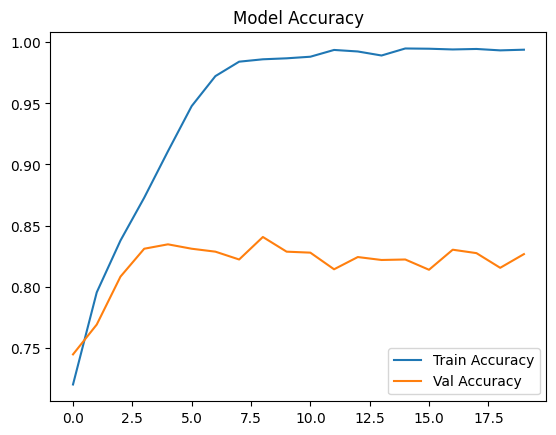

In [ ]:
# Plotting Accuracy
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Model Accuracy')
plt.legend()
plt.show()

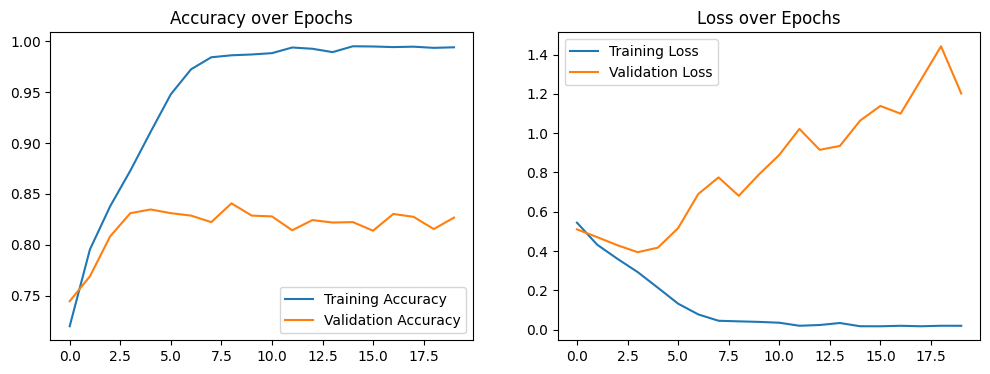

In [ ]:
# Plot results
def plot_results(history):
    plt.figure(figsize=(12, 4))

    # Accuracy Plot
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Training Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title('Accuracy over Epochs')
    plt.legend()

    # Loss Plot
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title('Loss over Epochs')
    plt.legend()
    plt.show()

plot_results(history)

In [ ]:
import os

drive_path = '/content/drive/MyDrive/Cats&Dogs Model'

os.makedirs(drive_path, exist_ok=True)
print(f"Directory '{drive_path}' ensured to exist.")

Directory '/content/drive/MyDrive/Cats&Dogs Model' ensured to exist.


In [ ]:
model_save_path = os.path.join(drive_path, 'cats_dogs_classifier.keras')
model.save(model_save_path)
print(f"Model saved successfully to {model_save_path}")

Model saved successfully to /content/drive/MyDrive/Cats&Dogs Model/cats_dogs_classifier.keras


In [ ]:
import shutil
import os

# Compress the PetImages directory into a zip archive
# The base_name is 'PetImages', format is 'zip', root_dir is '/content', and base_dir is 'PetImages'
shutil.make_archive('PetImages', 'zip', '/content', 'PetImages')
print("Created PetImages.zip in /content")

# Define the source path of the zip file and the destination path in Google Drive
zip_source_path = '/content/PetImages.zip'
drive_destination_path = os.path.join(drive_path, 'PetImages.zip')

# Move the zip file to the Google Drive directory
shutil.move(zip_source_path, drive_destination_path)
print(f"Moved PetImages.zip to {drive_destination_path}")

Created PetImages.zip in /content
Moved PetImages.zip to /content/drive/MyDrive/Cats&Dogs Model/PetImages.zip


In [ ]:
import shutil
import os

# Compress the SplitData directory into a zip archive
shutil.make_archive('SplitData', 'zip', '/content', 'SplitData')
print("Created SplitData.zip in /content")

# Define the source path of the zip file and the destination path in Google Drive
zip_source_path = '/content/SplitData.zip'
drive_destination_path = os.path.join(drive_path, 'SplitData.zip')

# Move the zip file to the Google Drive directory
shutil.move(zip_source_path, drive_destination_path)
print(f"Moved SplitData.zip to {drive_destination_path}")

Created SplitData.zip in /content
Moved SplitData.zip to /content/drive/MyDrive/Cats&Dogs Model/SplitData.zip


#Model V2

####Lode the base model

In [11]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import load_model
from tensorflow.keras.callbacks import EarlyStopping

model_path = "/content/drive/MyDrive/cats_dogs_classifier.keras"

model = load_model(model_path)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,914,309 (37.82 MB)

 Trainable params: 3,304,769 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 6,609,540 (25.21 MB)

Data preprocessing (Improved preprocessing / augmentation)

In [12]:
train_genV2 = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

val_genV2 = ImageDataGenerator(rescale=1./255)
test_genV2 = ImageDataGenerator(rescale=1./255)

In [13]:
train_generator = train_genV2.flow_from_directory(
    "SplitData/train",
    target_size=(128,128),
    batch_size=32,
    class_mode='binary'
)

val_generator = val_genV2.flow_from_directory(
    "SplitData/val",
    target_size=(128,128),
    batch_size=32,
    class_mode='binary'
)

test_generator = test_genV2.flow_from_directory(
    "SplitData/test",
    target_size=(128,128),
    batch_size=32,
    class_mode='binary'
)

Found 19998 images belonging to 2 classes.
Found 2498 images belonging to 2 classes.
Found 2502 images belonging to 2 classes.


In [14]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

#####Got UserWarning : 'Truncated File Read' UserWarning from PIL

In [19]:
history = model.fit(
    train_generator,
    epochs=30,
    validation_data=val_generator,
    callbacks=[early_stop]
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/30
479/625 ━━━━━━━━━━━━━━━━━━━━ 27s 191ms/step - accuracy: 0.7936 - loss: 0.5264

/usr/local/lib/python3.12/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))


625/625 ━━━━━━━━━━━━━━━━━━━━ 128s 197ms/step - accuracy: 0.7992 - loss: 0.5016 - val_accuracy: 0.8983 - val_loss: 0.2404
Epoch 2/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 115s 185ms/step - accuracy: 0.8533 - loss: 0.3357 - val_accuracy: 0.9211 - val_loss: 0.1888
Epoch 3/30
225/625 ━━━━━━━━━━━━━━━━━━━━ 1:11 178ms/step - accuracy: 0.8684 - loss: 0.3064

KeyboardInterrupt: 

In [16]:
history = model.fit(
    train_generator,
    epochs=30,
    validation_data=val_generator,
    callbacks=[early_stop]
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 128s 196ms/step - accuracy: 0.7902 - loss: 0.5127 - val_accuracy: 0.9247 - val_loss: 0.2030
Epoch 2/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 115s 185ms/step - accuracy: 0.8506 - loss: 0.3459 - val_accuracy: 0.9155 - val_loss: 0.2067
Epoch 3/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 116s 185ms/step - accuracy: 0.8653 - loss: 0.3087 - val_accuracy: 0.9331 - val_loss: 0.1767
Epoch 4/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 117s 187ms/step - accuracy: 0.8770 - loss: 0.2777 - val_accuracy: 0.9251 - val_loss: 0.1748
Epoch 5/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 116s 186ms/step - accuracy: 0.8880 - loss: 0.2657 - val_accuracy: 0.9311 - val_loss: 0.1713
Epoch 6/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 116s 185ms/step - accuracy: 0.8914 - loss: 0.2512 - val_accuracy: 0.9363 - val_loss: 0.1744
Epoch 7/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 116s 186ms/step - accuracy: 0.8992 - loss: 0.2442 - val_accuracy: 0.9211 - val_loss: 0.1954
Epoch 8/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 117s 187ms/step - accuracy: 0.9027 -

In [17]:
model.save("/content/drive/MyDrive/cats_dogs_retrained.keras")

Predicting on test data...
79/79 ━━━━━━━━━━━━━━━━━━━━ 4s 53ms/step


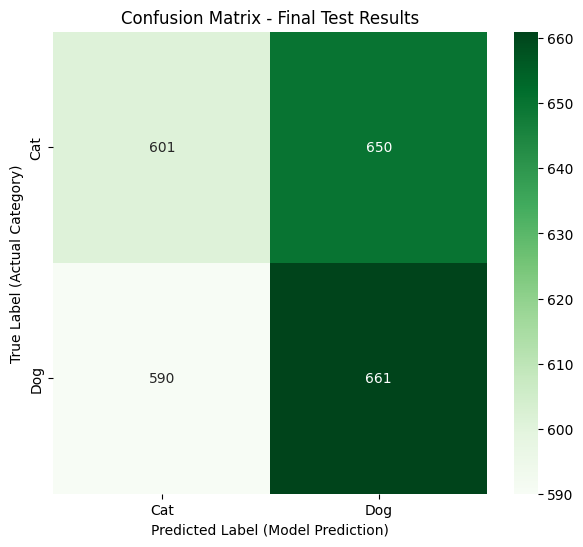


--- Classification Report ---
              precision    recall  f1-score   support

         Cat       0.50      0.48      0.49      1251
         Dog       0.50      0.53      0.52      1251

    accuracy                           0.50      2502
   macro avg       0.50      0.50      0.50      2502
weighted avg       0.50      0.50      0.50      2502



In [25]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

test_gen.reset()

print("Predicting on test data...")
predictions = model.predict(test_generator)
y_pred = (predictions > 0.5).astype(int).flatten()

y_true = test_generator.classes

cm = confusion_matrix(y_true, y_pred);

plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Cat', 'Dog'],
            yticklabels=['Cat', 'Dog'])
plt.xlabel('Predicted Label (Model Prediction)')
plt.ylabel('True Label (Actual Category)')
plt.title('Confusion Matrix - Final Test Results')
plt.show()

print("\n--- Classification Report ---")
print(classification_report(y_true, y_pred, target_names=['Cat', 'Dog']))

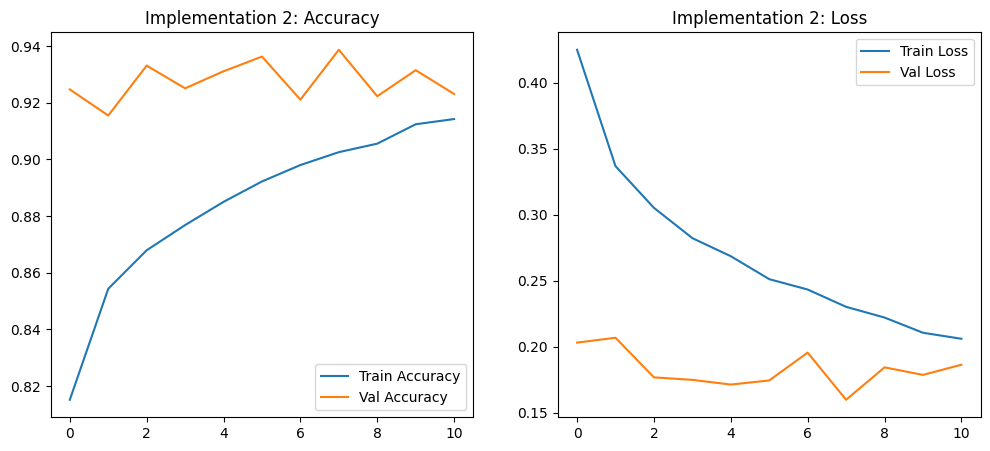

In [22]:
import matplotlib.pyplot as plt

# Accuracy Plot
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Implementation 2: Accuracy')
plt.legend()

# Loss Plot
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Implementation 2: Loss')
plt.legend()

plt.show()

#Model V3

In [26]:
import tensorflow as tf
from tensorflow.keras import layers, models

# Define the model architecture again
fresh_model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(128, 128, 3)),
    layers.MaxPooling2D(2, 2),

    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),

    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

# Compile the new model
fresh_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

fresh_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,304,769 (12.61 MB)

 Trainable params: 3,304,769 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

##### Filter out the specific 'Truncated File Read' UserWarning from PIL

In [28]:
from PIL import ImageFile
import warnings

ImageFile.LOAD_TRUNCATED_IMAGES = True

warnings.filterwarnings("ignore", category=UserWarning, module='PIL.TiffImagePlugin')

In [29]:
print("Training fresh model...")
fresh_history = fresh_model.fit(
    train_generator,
    epochs=30, # Increased epochs as EarlyStopping will handle overfitting
    validation_data=val_generator,
    callbacks=[early_stop]
)

Training fresh model...
Epoch 1/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 129s 207ms/step - accuracy: 0.7422 - loss: 0.5228 - val_accuracy: 0.7858 - val_loss: 0.4655
Epoch 2/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 121s 193ms/step - accuracy: 0.7687 - loss: 0.4797 - val_accuracy: 0.8042 - val_loss: 0.4155
Epoch 3/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 130s 209ms/step - accuracy: 0.7905 - loss: 0.4450 - val_accuracy: 0.8127 - val_loss: 0.4204
Epoch 4/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 125s 200ms/step - accuracy: 0.8139 - loss: 0.4093 - val_accuracy: 0.8106 - val_loss: 0.4160
Epoch 5/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 114s 182ms/step - accuracy: 0.8260 - loss: 0.3868 - val_accuracy: 0.8471 - val_loss: 0.3402
Epoch 6/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 121s 193ms/step - accuracy: 0.8357 - loss: 0.3623 - val_accuracy: 0.8451 - val_loss: 0.3537
Epoch 7/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 117s 188ms/step - accuracy: 0.8461 - loss: 0.3496 - val_accuracy: 0.8439 - val_loss: 0.3559
Epoch 8/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 122s 195ms/s

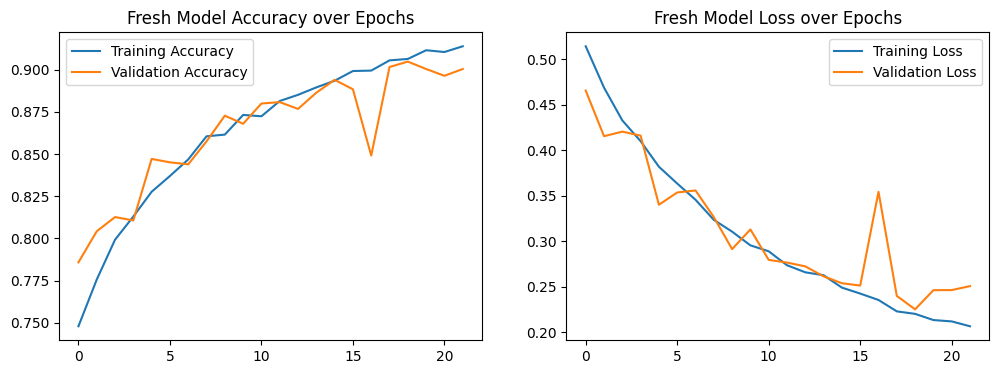

In [30]:
import matplotlib.pyplot as plt

def plot_fresh_results(history):
    plt.figure(figsize=(12, 4))

    # Accuracy Plot
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Training Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title('Fresh Model Accuracy over Epochs')
    plt.legend()

    # Loss Plot
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title('Fresh Model Loss over Epochs')
    plt.legend()
    plt.show()

plot_fresh_results(fresh_history)

In [31]:
fresh_model.save("/content/drive/MyDrive/cats_dogs_fresh_model.keras")

Predicting on test data with fresh model...
79/79 ━━━━━━━━━━━━━━━━━━━━ 5s 53ms/step


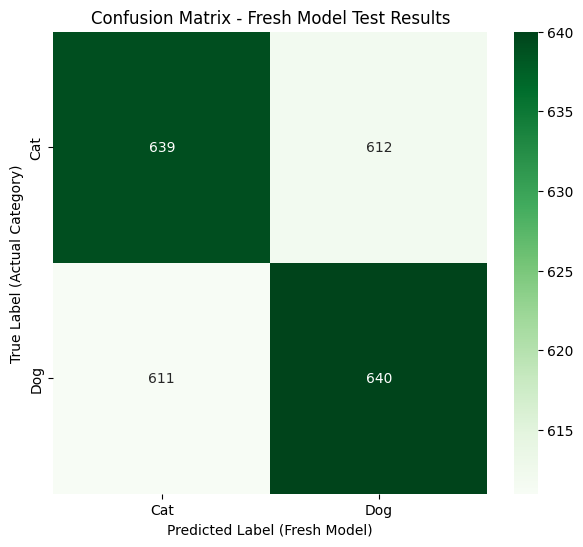


--- Classification Report (Fresh Model) ---
              precision    recall  f1-score   support

         Cat       0.51      0.51      0.51      1251
         Dog       0.51      0.51      0.51      1251

    accuracy                           0.51      2502
   macro avg       0.51      0.51      0.51      2502
weighted avg       0.51      0.51      0.51      2502



In [32]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

test_generator.reset()

print("Predicting on test data with fresh model...")
predictions_fresh = fresh_model.predict(test_generator)
y_pred_fresh = (predictions_fresh > 0.5).astype(int).flatten()

y_true_fresh = test_generator.classes

cm_fresh = confusion_matrix(y_true_fresh, y_pred_fresh);

plt.figure(figsize=(7, 6))
sns.heatmap(cm_fresh, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Cat', 'Dog'],
            yticklabels=['Cat', 'Dog'])
plt.xlabel('Predicted Label (Fresh Model)')
plt.ylabel('True Label (Actual Category)')
plt.title('Confusion Matrix - Fresh Model Test Results')
plt.show()

print("\n--- Classification Report (Fresh Model) ---")
print(classification_report(y_true_fresh, y_pred_fresh, target_names=['Cat', 'Dog']))